In [2]:
# Cell 1: Thư viện và Cấu hình tham số hệ thống
from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn thư mục dữ liệu
TRAIN_DIR = Path("../../TinHieuHuanLuyen")
TEST_DIR = Path("../../TinHieuKiemThu")
OUTPUT_DIR = Path("output/mine")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình tham số DSP theo yêu cầu giảng viên (Cùng cấu hình với TT1 để đối chiếu)
FRAME_MS = 25        # Độ dài frame (ms)
HOP_MS = 10          # Bước trượt frame (ms)
MIN_SILENCE_MS = 200 # Khoảng lặng tối thiểu (ms) để lọc khoảng lặng ảo


In [3]:
# Cell 2: Các hàm xử lý âm thanh cơ bản (Đọc WAV, LAB, tính STE)
def read_wav(wav_path):
    """Đọc file WAV 16-bit PCM, chuẩn hóa biên độ về [-1, 1], lấy fs và giá trị max biên độ gốc."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        samples = wf.readframes(wf.getnframes())
    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    max_amp = np.max(np.abs(signal))
    return signal / max_amp, fs, max_amp


def read_lab(lab_path):
    """Đọc file nhãn .lab, trả về biên chuẩn ground-truth (start, end) của vùng tiếng nói (v và uv)."""
    speech = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            speech.append((float(parts[0]), float(parts[1])))
    return round(min(s[0] for s in speech), 4), round(max(s[1] for s in speech), 4)


def compute_ste(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Chia tín hiệu thành các frame và tính Short-Time Energy (STE) chuẩn hóa [0, 1]."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    ste = np.zeros(n_frames)
    frame_starts = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_size
        frame = np.zeros(frame_size)
        avail = signal[start : min(start + frame_size, len(signal))]
        frame[:len(avail)] = avail
        ste[i] = np.mean(frame ** 2)
        frame_starts[i] = start / fs

    max_ste = float(np.max(ste))
    ste_norm = ste / max(max_ste, 1e-12)
    return ste_norm, frame_starts, max_ste


In [4]:
# Cell 3: Lớp mô hình VAD Histogram (Giannakopoulos 2014) & Khảo sát tập Train
class HistogramVAD:
    """
    Mô hình VAD xác định ngưỡng thích nghi (Adaptive Threshold) từ biểu đồ Histogram của STE.
    Thuật toán tìm 2 đỉnh cực đại: M1 (Silence) và M2 (Speech).
    Công thức ngưỡng: T = (Weight * M1 + M2) / (Weight + 1).
    """
    def __init__(self, bins=100, smoothing_width=5, weight=5.0):
        self.bins = bins
        self.smoothing_width = smoothing_width
        self.weight = weight

    def estimate_threshold(self, ste_norm):
        """Tính histogram của STE, làm trơn và tìm 2 đỉnh M1, M2 để tính ngưỡng thích nghi T."""
        counts, edges = np.histogram(ste_norm, bins=self.bins, range=(0.0, 1.0))
        centers = (edges[:-1] + edges[1:]) / 2.0
        half = self.smoothing_width // 2
        smooth = np.array([counts[max(0, i - half):min(len(counts), i + half + 1)].mean() for i in range(len(counts))])

        # Tìm các đỉnh cực đại địa phương (local peaks)
        peaks = []
        if smooth[0] >= smooth[1]:
            peaks.append(0)
        for i in range(1, len(smooth) - 1):
            if smooth[i] > smooth[i - 1] and smooth[i] >= smooth[i + 1]:
                peaks.append(i)

        # Đảm bảo có ít nhất 2 đỉnh
        if len(peaks) < 2:
            first = int(np.argmax(smooth))
            candidates = [i for i in range(len(smooth)) if abs(i - first) > 2]
            second = max(candidates, key=lambda i: smooth[i]) if candidates else min(first + 3, len(smooth) - 1)
            peaks = sorted([first, second])

        m1, m2 = float(centers[peaks[0]]), float(centers[peaks[1]])
        threshold = float((self.weight * m1 + m2) / (self.weight + 1.0))
        return threshold, m1, m2, centers, smooth

    def predict(self, ste_norm, frame_starts, duration):
        """Tính ngưỡng T của file, phân lớp frame và lấp khoảng lặng ảo < 200 ms."""
        threshold, m1, m2, centers, smooth = self.estimate_threshold(ste_norm)
        labels = (ste_norm >= threshold).astype(int)
        min_silence_frames = int(round(MIN_SILENCE_MS / HOP_MS))
        speech_idx = np.flatnonzero(labels == 1)
        if len(speech_idx) == 0:
            return (0.0, 0.0), labels, threshold, m1, m2, centers, smooth

        # Lấp các khoảng lặng ngắn hơn 200 ms nằm bên trong vùng tiếng nói
        idx, last = int(speech_idx[0]), int(speech_idx[-1])
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
            else:
                sil_start = idx
                while idx <= last and labels[idx] == 0:
                    idx += 1
                if idx - sil_start < min_silence_frames:
                    labels[sil_start:idx] = 1

        # Xác định mốc thời gian bắt đầu và kết thúc (giây)
        speech_idx = np.flatnonzero(labels == 1)
        start_time = float(frame_starts[speech_idx[0]])
        end_time = min(duration, float(frame_starts[speech_idx[-1]] + FRAME_MS / 1000.0))
        return (round(start_time, 4), round(end_time, 4)), labels, threshold, m1, m2, centers, smooth


# Khảo sát mô hình trên 4 file Huấn luyện (Train Data)
model = HistogramVAD(bins=100, smoothing_width=5, weight=5.0)

print("=" * 96)
print(f"{'KHẢO SÁT THUẬT TOÁN HISTOGRAM TRÊN TẬP HUẤN LUYỆN (TRAIN EVALUATION)':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Đỉnh M1 (Sil)':<13} | {'Đỉnh M2 (Sp)':<13} | {'Ngưỡng T':<12} | {'Biên Chuẩn':<16} | {'Biên Đoán':<16} | {'MAE (ms)':<8}")
print("-" * 96)

train_maes = []
for wav_file in sorted(TRAIN_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt = read_lab(wav_file.with_suffix(".lab"))
    pred, _, T, m1, m2, _, _ = model.predict(ste_norm, frame_starts, len(signal) / fs)
    d_st = (pred[0] - gt[0]) * 1000.0
    d_en = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_st) + abs(d_en)) / 2.0
    train_maes.append(mae)
    print(f"{wav_file.name:<16} | {m1:<13.4f} | {m2:<13.4f} | {T:<12.6f} | [{gt[0]:.2f}, {gt[1]:.2f}]       | [{pred[0]:.2f}, {pred[1]:.2f}]       | {mae:8.2f}")

print("-" * 96)
print(f"Train Mean MAE = {np.mean(train_maes):.2f} ms")
print("=" * 96)


              KHẢO SÁT THUẬT TOÁN HISTOGRAM TRÊN TẬP HUẤN LUYỆN (TRAIN EVALUATION)              
File             | Đỉnh M1 (Sil) | Đỉnh M2 (Sp)  | Ngưỡng T     | Biên Chuẩn       | Biên Đoán        | MAE (ms)
------------------------------------------------------------------------------------------------
phone_F1.wav     | 0.0050        | 0.0650        | 0.015000     | [0.53, 2.75]       | [0.54, 2.75]       |     7.50
phone_M1.wav     | 0.0050        | 0.1050        | 0.021667     | [0.46, 3.52]       | [0.46, 3.52]       |     2.50
studio_F1.wav    | 0.0050        | 0.0650        | 0.015000     | [0.68, 2.15]       | [0.67, 2.15]       |     7.50
studio_M1.wav    | 0.0050        | 0.0650        | 0.015000     | [0.87, 2.06]       | [0.91, 2.04]       |    27.50
------------------------------------------------------------------------------------------------
Train Mean MAE = 11.25 ms


In [5]:
# Cell 4: Đánh giá mô hình trên tập Kiểm thử (Test Data) - Báo cáo MAE và RMSE (ms)
test_results = []
print("=" * 96)
print(f"{'BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Biên Chuẩn (s)':<16} | {'Biên Đoán (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)

for wav_file in sorted(TEST_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    duration = len(signal) / fs
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt = read_lab(wav_file.with_suffix(".lab"))
    pred, labels, T, m1, m2, centers, smooth = model.predict(ste_norm, frame_starts, duration)

    # Tính sai số biên theo mili-giây (ms)
    d_start = (pred[0] - gt[0]) * 1000.0
    d_end = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_start) + abs(d_end)) / 2.0
    rmse = np.sqrt((d_start**2 + d_end**2) / 2.0)

    test_results.append({
        "file": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "gt": gt,
        "pred": pred,
        "labels": labels,
        "T": T,
        "m1": m1,
        "m2": m2,
        "centers": centers,
        "smooth": smooth,
        "d_start": d_start,
        "d_end": d_end,
        "mae": mae,
        "rmse": rmse,
    })

    gt_str = f"[{gt[0]:.2f}, {gt[1]:.2f}]"
    pred_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{wav_file.name:<16} | {gt_str:<16} | {pred_str:<16} | {d_start:+8.1f} ms | {d_end:+8.1f} ms | {mae:9.2f} | {rmse:9.2f}")

mean_mae = np.mean([r["mae"] for r in test_results])
mean_rmse = np.mean([r["rmse"] for r in test_results])
print("-" * 96)
print(f"TỔNG KẾT TẬP TEST (TT2):  Mean MAE = {mean_mae:.2f} ms  |  Mean RMSE = {mean_rmse:.2f} ms")
print("=" * 96)


                  BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)                  
File             | Biên Chuẩn (s)   | Biên Đoán (s)    | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.05, 4.01]     |    +30.0 ms |    -25.0 ms |     27.50 |     27.61
phone_M2.wav     | [0.53, 2.52]     | [0.53, 2.52]     |     +0.0 ms |     -5.0 ms |      2.50 |      3.54
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.35]     |    -10.0 ms |    -25.0 ms |     17.50 |     19.04
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.92]     |    +10.0 ms |    -15.0 ms |     12.50 |     12.75
------------------------------------------------------------------------------------------------
TỔNG KẾT TẬP TEST (TT2):  Mean MAE = 15.00 ms  |  Mean RMSE = 15.73 ms


Đã xuất và lưu: output\mine\phone_F2.png


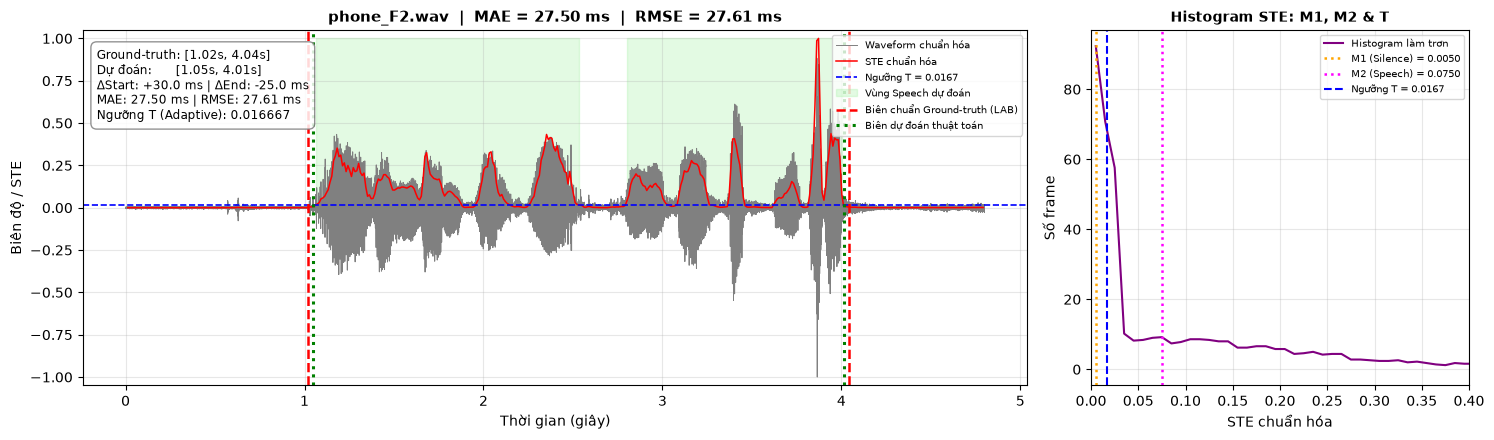

Đã xuất và lưu: output\mine\phone_M2.png


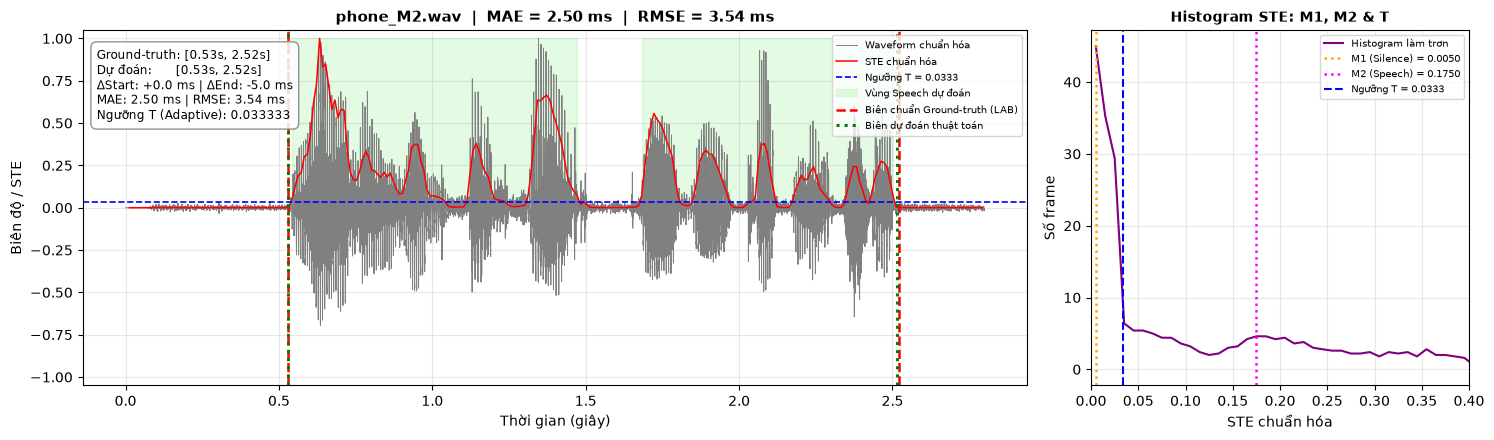

Đã xuất và lưu: output\mine\studio_F2.png


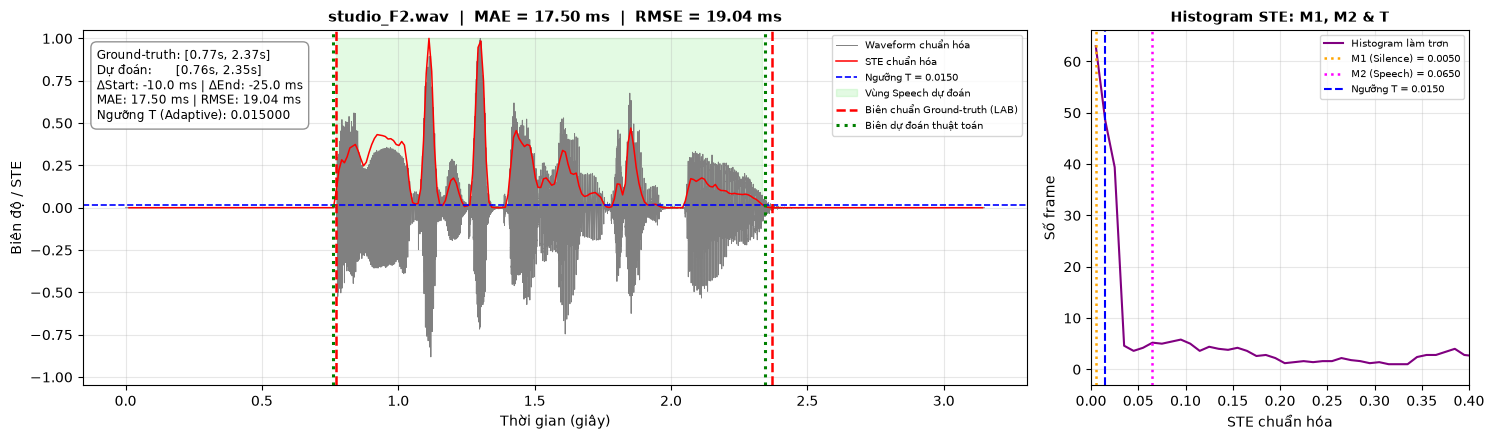

Đã xuất và lưu: output\mine\studio_M2.png


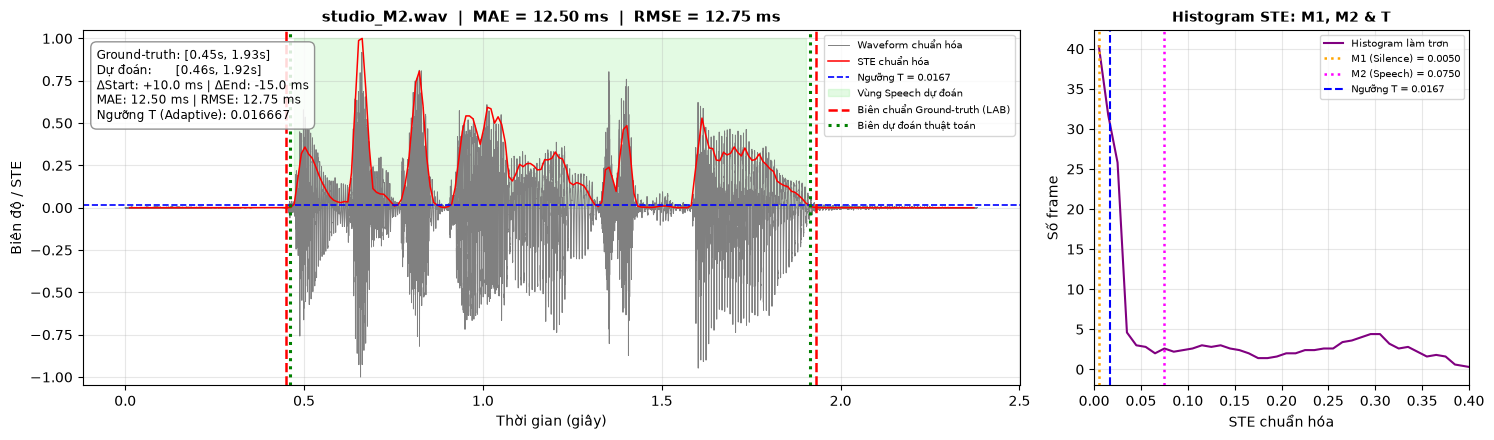

In [6]:
# Cell 5: Xuất 4 figure kiểm thử riêng biệt (Waveform/STE + Biểu đồ Histogram)
for res in test_results:
    fig, (ax_main, ax_hist) = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2.5, 1]})
    time_signal = np.arange(len(res["signal"])) / res["fs"]
    frame_centers = res["frame_starts"] + (FRAME_MS / 2000.0)

    # 1. Đồ thị chính: Waveform và STE chuẩn hóa
    ax_main.plot(time_signal, res["signal"], color="gray", linewidth=0.7, label="Waveform chuẩn hóa")
    ax_main.plot(frame_centers, res["ste_norm"], color="red", linewidth=1.1, label="STE chuẩn hóa")
    ax_main.axhline(res["T"], color="blue", linestyle="--", linewidth=1.2, label=f"Ngưỡng T = {res['T']:.4f}")
    ax_main.fill_between(frame_centers, 0, 1, where=res["labels"] == 1, color="lightgreen", alpha=0.25, label="Vùng Speech dự đoán")

    ax_main.axvline(res["gt"][0], color="red", linestyle="--", linewidth=1.8, label="Biên chuẩn Ground-truth (LAB)")
    ax_main.axvline(res["gt"][1], color="red", linestyle="--", linewidth=1.8)
    ax_main.axvline(res["pred"][0], color="green", linestyle=":", linewidth=2.2, label="Biên dự đoán thuật toán")
    ax_main.axvline(res["pred"][1], color="green", linestyle=":", linewidth=2.2)

    ax_main.set_title(f"{res['file']}  |  MAE = {res['mae']:.2f} ms  |  RMSE = {res['rmse']:.2f} ms", fontsize=11, fontweight="bold")
    ax_main.set_xlabel("Thời gian (giây)")
    ax_main.set_ylabel("Biên độ / STE")
    ax_main.set_ylim(-1.05, 1.05)
    ax_main.grid(alpha=0.3)
    ax_main.legend(loc="upper right", fontsize=7.5)

    # Hộp thông số chi tiết trên đồ thị
    info_text = (
        f"Ground-truth: [{res['gt'][0]:.2f}s, {res['gt'][1]:.2f}s]\n"
        f"Dự đoán:      [{res['pred'][0]:.2f}s, {res['pred'][1]:.2f}s]\n"
        f"ΔStart: {res['d_start']:+.1f} ms | ΔEnd: {res['d_end']:+.1f} ms\n"
        f"MAE: {res['mae']:.2f} ms | RMSE: {res['rmse']:.2f} ms\n"
        f"Ngưỡng T (Adaptive): {res['T']:.6f}"
    )
    ax_main.text(0.015, 0.95, info_text, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

    # 2. Đồ thị phụ: Histogram STE với 2 đỉnh M1, M2 và ngưỡng T
    ax_hist.plot(res["centers"], res["smooth"], color="purple", linewidth=1.5, label="Histogram làm trơn")
    ax_hist.axvline(res["m1"], color="orange", linestyle=":", linewidth=1.8, label=f"M1 (Silence) = {res['m1']:.4f}")
    ax_hist.axvline(res["m2"], color="magenta", linestyle=":", linewidth=1.8, label=f"M2 (Speech) = {res['m2']:.4f}")
    ax_hist.axvline(res["T"], color="blue", linestyle="--", linewidth=1.5, label=f"Ngưỡng T = {res['T']:.4f}")
    ax_hist.set_title("Histogram STE: M1, M2 & T", fontsize=10, fontweight="bold")
    ax_hist.set_xlabel("STE chuẩn hóa")
    ax_hist.set_ylabel("Số frame")
    ax_hist.set_xlim(0, 0.4)
    ax_hist.grid(alpha=0.3)
    ax_hist.legend(loc="upper right", fontsize=7)

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{Path(res['file']).stem}.png"
    plt.savefig(fig_path, dpi=150)
    print(f"Đã xuất và lưu: {fig_path}")
    plt.show()
